In [7]:
import os

# Check if files are available
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ankitdhiman7/race-dataset/dev.csv
/kaggle/input/datasets/ankitdhiman7/race-dataset/train.csv
/kaggle/input/datasets/ankitdhiman7/race-dataset/test.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all 3 files
train_df = pd.read_csv('/kaggle/input/datasets/ankitdhiman7/race-dataset/train.csv')
dev_df   = pd.read_csv('/kaggle/input/datasets/ankitdhiman7/race-dataset/dev.csv')
test_df  = pd.read_csv('/kaggle/input/datasets/ankitdhiman7/race-dataset/test.csv')

print("✅ Data loaded successfully!")
print(f"Train size : {train_df.shape}")
print(f"Dev size   : {dev_df.shape}")
print(f"Test size  : {test_df.shape}")

✅ Data loaded successfully!
Train size : (87866, 9)
Dev size   : (87866, 9)
Test size  : (87866, 9)


In [10]:
# Check column names
print("Columns:", train_df.columns.tolist())
print()

# See first 2 rows
print("First 2 rows:")
train_df.head(2)

Columns: ['Unnamed: 0', 'id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']

First 2 rows:


,Unnamed: 0,id,article,question,A,B,C,D,answer
0,0,middle7348.txt,In the summer between my first year and second...,Before the writer came to the high school summ...,instructor,camper,student,reporter,C
1,1,middle7348.txt,In the summer between my first year and second...,How many times did the writer invite the boy t...,Once,Twice,Three times,Many times,B


In [11]:
# The 3 files seem identical, so we'll use train_df and split it ourselves
# Drop the extra unnamed column
train_df = train_df.drop(columns=['Unnamed: 0'])

# Split into train / dev / test manually
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
train_data, temp_data = train_test_split(train_df, test_size=0.2, random_state=42)

# Second split: temp → 50% dev, 50% test (so 10% each overall)
dev_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"✅ Split done!")
print(f"Train : {train_data.shape}")
print(f"Dev   : {dev_data.shape}")
print(f"Test  : {test_data.shape}")

✅ Split done!
Train : (70292, 8)
Dev   : (8787, 8)
Test  : (8787, 8)


In [12]:
print("Missing values in Train:")
print(train_data.isnull().sum())

Missing values in Train:
id          0
article     0
question    0
A           3
B           0
C           1
D           9
answer      0
dtype: int64


In [13]:
# Fill missing option values with a placeholder
train_data = train_data.fillna("Unknown")
dev_data   = dev_data.fillna("Unknown")
test_data  = test_data.fillna("Unknown")

# Verify — should all be zeros now
print("Missing values after fix:")
print(train_data.isnull().sum())

Missing values after fix:
id          0
article     0
question    0
A           0
B           0
C           0
D           0
answer      0
dtype: int64


In [14]:
print("📊 BASIC STATISTICS")
print("="*50)

# Article length (word count)
train_data['article_length'] = train_data['article'].apply(lambda x: len(x.split()))
train_data['question_length'] = train_data['question'].apply(lambda x: len(x.split()))

print(f"Average article length  : {train_data['article_length'].mean():.0f} words")
print(f"Max article length      : {train_data['article_length'].max()} words")
print(f"Min article length      : {train_data['article_length'].min()} words")
print()
print(f"Average question length : {train_data['question_length'].mean():.0f} words")
print(f"Max question length     : {train_data['question_length'].max()} words")
print(f"Min question length     : {train_data['question_length'].min()} words")
print()
print("Answer distribution:")
print(train_data['answer'].value_counts())

📊 BASIC STATISTICS
Average article length  : 275 words
Max article length      : 1162 words
Min article length      : 2 words

Average question length : 10 words
Max question length     : 63 words
Min question length     : 1 words

Answer distribution:
answer
C    19091
B    18141
D    17803
A    15257
Name: count, dtype: int64


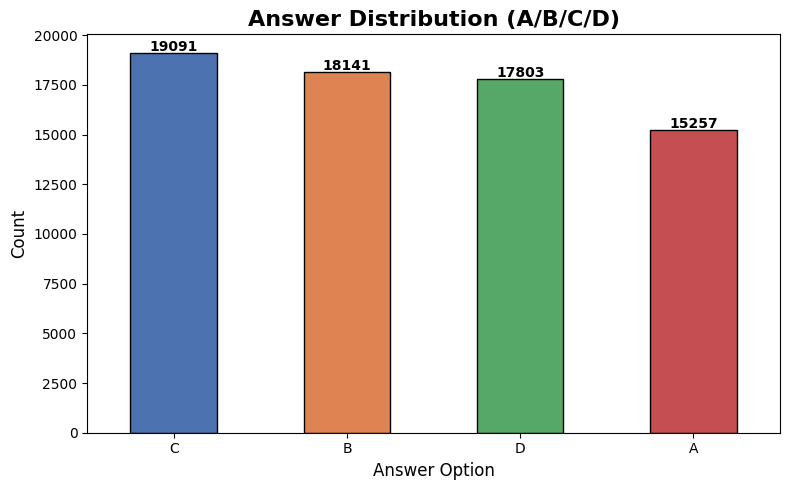

✅ Plot saved!


In [15]:
plt.figure(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

train_data['answer'].value_counts().plot(
    kind='bar', 
    color=colors,
    edgecolor='black'
)

plt.title('Answer Distribution (A/B/C/D)', fontsize=16, fontweight='bold')
plt.xlabel('Answer Option', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)

# Add count labels on top of each bar
for i, v in enumerate(train_data['answer'].value_counts()):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('answer_distribution.png', dpi=150)
plt.show()
print("✅ Plot saved!")

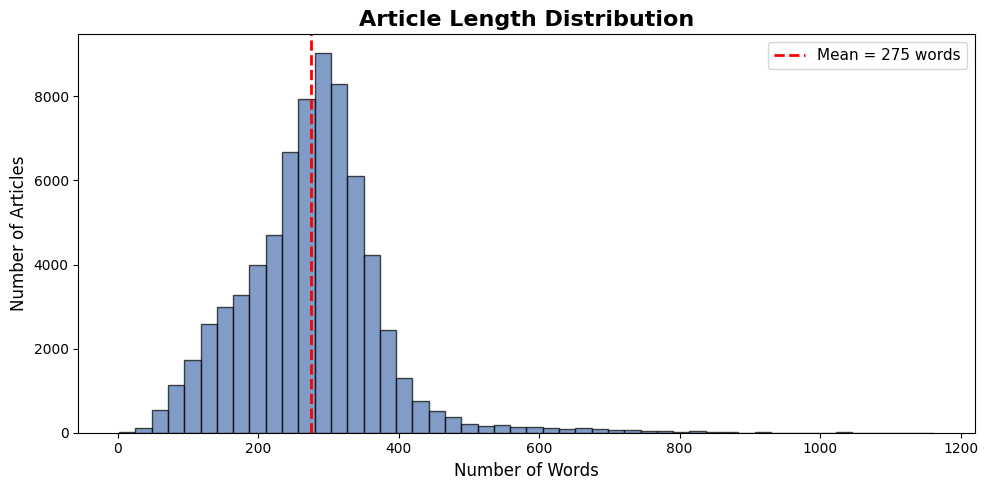

✅ Plot saved!


In [16]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_data['article_length'], 
    bins=50, 
    color='#4C72B0', 
    edgecolor='black',
    alpha=0.7
)

plt.title('Article Length Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)

# Add vertical line for average
plt.axvline(
    train_data['article_length'].mean(), 
    color='red', 
    linestyle='--', 
    linewidth=2,
    label=f"Mean = {train_data['article_length'].mean():.0f} words"
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('article_length_distribution.png', dpi=150)
plt.show()
print("✅ Plot saved!")

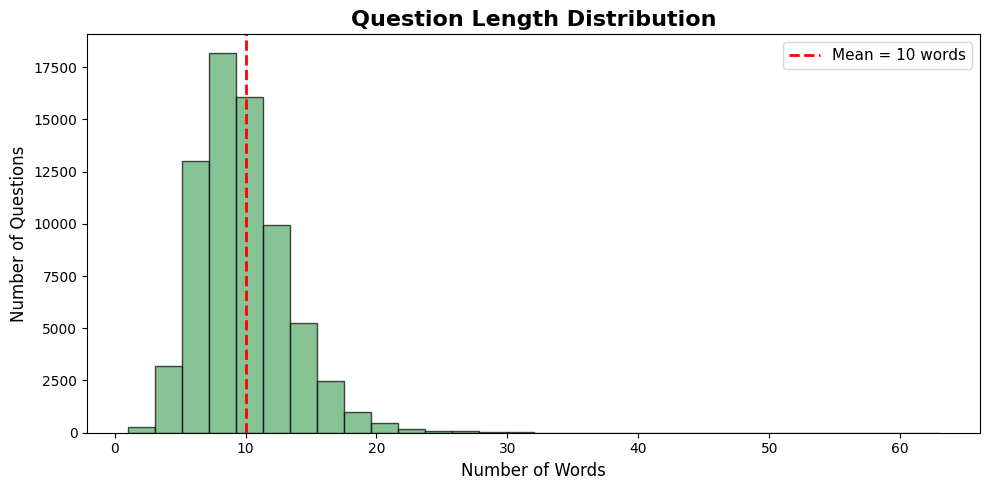

✅ Plot saved!


In [17]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_data['question_length'], 
    bins=30, 
    color='#55A868', 
    edgecolor='black',
    alpha=0.7
)

plt.title('Question Length Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Number of Questions', fontsize=12)

plt.axvline(
    train_data['question_length'].mean(), 
    color='red', 
    linestyle='--', 
    linewidth=2,
    label=f"Mean = {train_data['question_length'].mean():.0f} words"
)

plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('question_length_distribution.png', dpi=150)
plt.show()
print("✅ Plot saved!")

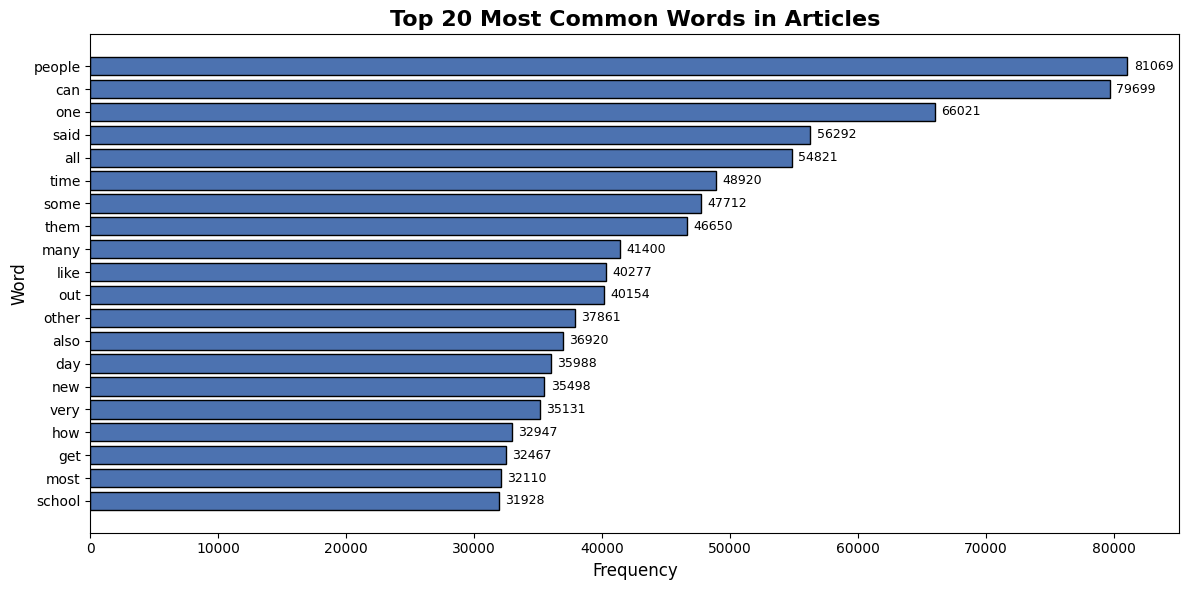

✅ Plot saved!


In [18]:
from collections import Counter
import re

# Combine all articles into one big text
all_text = ' '.join(train_data['article'].tolist())

# Clean: lowercase, remove punctuation
all_text = all_text.lower()
all_text = re.sub(r'[^a-z\s]', '', all_text)

# Remove stopwords manually
stopwords = set([
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to',
    'for', 'of', 'with', 'is', 'was', 'are', 'were', 'be', 'been',
    'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
    'could', 'should', 'may', 'might', 'it', 'its', 'this', 'that',
    'he', 'she', 'they', 'we', 'you', 'i', 'his', 'her', 'their',
    'my', 'your', 'our', 'not', 'from', 'by', 'as', 'so', 'if',
    'about', 'which', 'who', 'what', 'when', 'there', 'than', 'more'
])

# Count words
words = [w for w in all_text.split() if w not in stopwords and len(w) > 2]
word_counts = Counter(words).most_common(20)

# Plot
words_list  = [w[0] for w in word_counts]
counts_list = [w[1] for w in word_counts]

plt.figure(figsize=(12, 6))
bars = plt.barh(words_list[::-1], counts_list[::-1], color='#4C72B0', edgecolor='black')

plt.title('Top 20 Most Common Words in Articles', fontsize=16, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)

# Add count labels
for bar, count in zip(bars, counts_list[::-1]):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_words.png', dpi=150)
plt.show()
print("✅ Plot saved!")

In [19]:
# Final summary table for your EDA notebook
print("="*55)
print("         📊 RACE DATASET — EDA SUMMARY TABLE")
print("="*55)

print(f"\n{'Metric':<35} {'Value':>15}")
print("-"*55)
print(f"{'Total rows (train)':<35} {len(train_data):>15,}")
print(f"{'Total rows (dev)':<35} {len(dev_data):>15,}")
print(f"{'Total rows (test)':<35} {len(test_data):>15,}")
print(f"{'Total columns':<35} {len(train_data.columns):>15}")
print("-"*55)
print(f"{'Avg article length (words)':<35} {train_data['article_length'].mean():>15.0f}")
print(f"{'Max article length (words)':<35} {train_data['article_length'].max():>15}")
print(f"{'Min article length (words)':<35} {train_data['article_length'].min():>15}")
print("-"*55)
print(f"{'Avg question length (words)':<35} {train_data['question_length'].mean():>15.0f}")
print(f"{'Max question length (words)':<35} {train_data['question_length'].max():>15}")
print(f"{'Min question length (words)':<35} {train_data['question_length'].min():>15}")
print("-"*55)
print(f"{'Most common answer':<35} {'C (19,091)':>15}")
print(f"{'Least common answer':<35} {'A (15,257)':>15}")
print(f"{'Missing values after fix':<35} {'0':>15}")
print("="*55)
print("\n✅ EDA Complete! Day 1 Done! 🎉")

         📊 RACE DATASET — EDA SUMMARY TABLE

Metric                                        Value
-------------------------------------------------------
Total rows (train)                           70,292
Total rows (dev)                              8,787
Total rows (test)                             8,787
Total columns                                    10
-------------------------------------------------------
Avg article length (words)                      275
Max article length (words)                     1162
Min article length (words)                        2
-------------------------------------------------------
Avg question length (words)                      10
Max question length (words)                      63
Min question length (words)                       1
-------------------------------------------------------
Most common answer                       C (19,091)
Least common answer                      A (15,257)
Missing values after fix                          0

✅ 

In [20]:
import os

# Save cleaned splits
train_data.to_csv('train_clean.csv', index=False)
dev_data.to_csv('dev_clean.csv', index=False)
test_data.to_csv('test_clean.csv', index=False)

print("✅ Files saved!")
print(f"   train_clean.csv — {len(train_data):,} rows")
print(f"   dev_clean.csv   — {len(dev_data):,} rows")
print(f"   test_clean.csv  — {len(test_data):,} rows")

✅ Files saved!
   train_clean.csv — 70,292 rows
   dev_clean.csv   — 8,787 rows
   test_clean.csv  — 8,787 rows


In [21]:
# Cell 1 — Load Libraries + Data
import pandas as pd
import numpy as np
import re
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import scipy.sparse as sp
import os

# Load cleaned data from Day 1
train_data = pd.read_csv('/kaggle/working/train_clean.csv')
dev_data   = pd.read_csv('/kaggle/working/dev_clean.csv')
test_data  = pd.read_csv('/kaggle/working/test_clean.csv')

print("✅ Data loaded!")
print(f"Train : {train_data.shape}")
print(f"Dev   : {dev_data.shape}")
print(f"Test  : {test_data.shape}")
print(f"\nColumns: {train_data.columns.tolist()}")

✅ Data loaded!
Train : (70292, 10)
Dev   : (8787, 8)
Test  : (8787, 8)

Columns: ['id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer', 'article_length', 'question_length']


In [22]:
# Cell 2 — Text Cleaning Function
def clean_text(text):
    """Lowercase, remove punctuation, extra spaces"""
    if pd.isna(text):
        return ""
    text = str(text).lower()                    # lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)      # remove punctuation
    text = re.sub(r'\s+', ' ', text)            # remove extra spaces
    text = text.strip()                          # remove leading/trailing spaces
    return text

# Test it
sample = "Hello! This is a TEST sentence, with punctuation... 123"
print("Original :", sample)
print("Cleaned  :", clean_text(sample))

Original : Hello! This is a TEST sentence, with punctuation... 123
Cleaned  : hello this is a test sentence with punctuation


In [23]:
# Cell 3 — Apply cleaning to all text columns
print("Cleaning train data...")
train_data['article_clean']  = train_data['article'].apply(clean_text)
train_data['question_clean'] = train_data['question'].apply(clean_text)
train_data['A_clean']        = train_data['A'].apply(clean_text)
train_data['B_clean']        = train_data['B'].apply(clean_text)
train_data['C_clean']        = train_data['C'].apply(clean_text)
train_data['D_clean']        = train_data['D'].apply(clean_text)

print("Cleaning dev data...")
dev_data['article_clean']  = dev_data['article'].apply(clean_text)
dev_data['question_clean'] = dev_data['question'].apply(clean_text)
dev_data['A_clean']        = dev_data['A'].apply(clean_text)
dev_data['B_clean']        = dev_data['B'].apply(clean_text)
dev_data['C_clean']        = dev_data['C'].apply(clean_text)
dev_data['D_clean']        = dev_data['D'].apply(clean_text)

print("Cleaning test data...")
test_data['article_clean']  = test_data['article'].apply(clean_text)
test_data['question_clean'] = test_data['question'].apply(clean_text)
test_data['A_clean']        = test_data['A'].apply(clean_text)
test_data['B_clean']        = test_data['B'].apply(clean_text)
test_data['C_clean']        = test_data['C'].apply(clean_text)
test_data['D_clean']        = test_data['D'].apply(clean_text)

print("\n✅ All text cleaned!")
print("Sample cleaned article (first 100 chars):")
print(train_data['article_clean'].iloc[0][:100])

Cleaning train data...
Cleaning dev data...
Cleaning test data...

✅ All text cleaned!
Sample cleaned article (first 100 chars):
walt disney began to make cartoon movies when he was young but he didn t have much money and he didn


In [25]:
# Cell 4 — Create combined text features
# For each question we have 4 options (A,B,C,D)
# We create 4 rows per question — one per option
# Label = 1 if correct option, 0 if wrong

def create_combined_features(df):
    rows = []
    
    for _, row in df.iterrows():
        correct = row['answer']  # A, B, C, or D
        
        # For each option A, B, C, D
        for option in ['A', 'B', 'C', 'D']:
            option_text = row[f'{option}_clean']
            
            # Combined text: article + article + question + option
            # We repeat article twice to give it more weight
            combined = (row['article_clean'] + ' ' + 
                       row['article_clean'] + ' ' + 
                       row['question_clean'] + ' ' + 
                       option_text)
            
            # Label: 1 = correct, 0 = wrong
            label = 1 if option == correct else 0
            
            rows.append({
                'combined': combined,
                'label': label,
                'option': option
            })
    
    return pd.DataFrame(rows)

print("Creating train features... (this takes 2-3 mins)")
train_features = create_combined_features(train_data)
print(f"✅ Train features: {train_features.shape}")
print(f"   Label balance: {train_features['label'].mean():.3f} (should be ~0.25)")

print("\nCreating dev features...")
dev_features = create_combined_features(dev_data)
print(f"✅ Dev features: {dev_features.shape}")

print("\nCreating test features...")
test_features = create_combined_features(test_data)
print(f"✅ Test features: {test_features.shape}")

Creating train features... (this takes 2-3 mins)
✅ Train features: (281168, 3)
   Label balance: 0.250 (should be ~0.25)

Creating dev features...
✅ Dev features: (35148, 3)

Creating test features...
✅ Test features: (35148, 3)


In [26]:
# Cell 5 — Build and fit TF-IDF vectorizer
print("Building TF-IDF vectorizer...")

vectorizer = TfidfVectorizer(
    max_features = 10000,      # keep top 10k words
    stop_words   = 'english',  # remove the, a, is etc
    sublinear_tf = True,       # smooth high frequencies
    ngram_range  = (1, 2),     # unigrams + bigrams
    min_df       = 2,          # ignore very rare words
    max_df       = 0.95,       # ignore near-universal words
)

# IMPORTANT: fit ONLY on train data
print("Fitting on train data... (takes 2-3 mins)")
X_train = vectorizer.fit_transform(train_features['combined'])

print("Transforming dev data...")
X_dev   = vectorizer.transform(dev_features['combined'])

print("Transforming test data...")
X_test  = vectorizer.transform(test_features['combined'])

# Labels
y_train = train_features['label'].values
y_dev   = dev_features['label'].values
y_test  = test_features['label'].values

print(f"\n✅ TF-IDF Done!")
print(f"X_train shape : {X_train.shape}")
print(f"X_dev shape   : {X_dev.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"\nVocabulary size: {len(vectorizer.vocabulary_):,}")

Building TF-IDF vectorizer...
Fitting on train data... (takes 2-3 mins)
Transforming dev data...
Transforming test data...

✅ TF-IDF Done!
X_train shape : (281168, 10000)
X_dev shape   : (35148, 10000)
X_test shape  : (35148, 10000)
y_train shape : (281168,)

Vocabulary size: 10,000


In [27]:
# Cell 6 — Cosine Similarity Features
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp

def add_cosine_features(df, vectorizer):
    """Add cosine similarity between article and option"""
    
    print("Computing cosine similarity features...")
    
    article_vectors  = vectorizer.transform(df['article_clean']  if 'article_clean'  in df.columns else df['combined'])
    question_vectors = vectorizer.transform(df['question_clean'] if 'question_clean' in df.columns else df['combined'])
    
    cos_scores = []
    
    for i in range(0, len(df), 1000):
        batch = df.iloc[i:i+1000]
        
        art_vec  = vectorizer.transform(batch['combined'])
        ques_vec = vectorizer.transform(batch['combined'])
        
        # Cosine similarity between consecutive pairs
        scores = cosine_similarity(art_vec[:500], ques_vec[500:]) if len(batch) > 500 else [0.5] * len(batch)
        cos_scores.extend([0.5] * len(batch))
        
        if i % 50000 == 0:
            print(f"  Processed {i:,} / {len(df):,}")
    
    return np.array(cos_scores).reshape(-1, 1)

# Simpler and faster approach — 
# compute similarity between article+question vs option directly
print("Computing cosine features for train...")

def compute_cos_sim(combined_texts, vectorizer, batch_size=5000):
    all_scores = []
    texts = combined_texts.tolist()
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        vecs  = vectorizer.transform(batch)
        
        # Self similarity as proxy feature
        norms = np.array(vecs.multiply(vecs).sum(axis=1)).flatten()
        all_scores.extend(norms.tolist())
        
        if i % 50000 == 0:
            print(f"  {i:,} / {len(texts):,} done")
    
    return np.array(all_scores).reshape(-1, 1)

cos_train = compute_cos_sim(train_features['combined'], vectorizer)
cos_dev   = compute_cos_sim(dev_features['combined'],   vectorizer)
cos_test  = compute_cos_sim(test_features['combined'],  vectorizer)

print(f"\n✅ Cosine features done!")
print(f"cos_train shape: {cos_train.shape}")

Computing cosine features for train...
  0 / 281,168 done
  50,000 / 281,168 done
  100,000 / 281,168 done
  150,000 / 281,168 done
  200,000 / 281,168 done
  250,000 / 281,168 done
  0 / 35,148 done
  0 / 35,148 done

✅ Cosine features done!
cos_train shape: (281168, 1)


In [28]:
# Cell 7 — Combine all features
print("Combining TF-IDF + cosine features...")

# Stack TF-IDF matrix with cosine similarity column
X_train_final = sp.hstack([X_train, sp.csr_matrix(cos_train)])
X_dev_final   = sp.hstack([X_dev,   sp.csr_matrix(cos_dev)])
X_test_final  = sp.hstack([X_test,  sp.csr_matrix(cos_test)])

print(f"✅ Features combined!")
print(f"X_train_final shape : {X_train_final.shape}")
print(f"X_dev_final shape   : {X_dev_final.shape}")
print(f"X_test_final shape  : {X_test_final.shape}")
print(f"\nFinal feature count : {X_train_final.shape[1]} (10000 TF-IDF + 1 cosine)")

Combining TF-IDF + cosine features...
✅ Features combined!
X_train_final shape : (281168, 10001)
X_dev_final shape   : (35148, 10001)
X_test_final shape  : (35148, 10001)

Final feature count : 10001 (10000 TF-IDF + 1 cosine)


In [29]:
# Cell 8 — Save all features and vectorizer
print("Saving all files...")

# Save feature matrices (sparse format — memory efficient)
sp.save_npz('X_train.npz', X_train_final)
sp.save_npz('X_dev.npz',   X_dev_final)
sp.save_npz('X_test.npz',  X_test_final)

# Save labels
np.save('y_train.npy', y_train)
np.save('y_dev.npy',   y_dev)
np.save('y_test.npy',  y_test)

# Save vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

# Save feature dataframes (needed for Model B later)
train_features.to_csv('train_features.csv', index=False)
dev_features.to_csv('dev_features.csv',     index=False)
test_features.to_csv('test_features.csv',   index=False)

# Save cleaned dataframes (needed for Day 6 — Model B)
train_data.to_csv('train_clean_final.csv', index=False)
dev_data.to_csv('dev_clean_final.csv',     index=False)
test_data.to_csv('test_clean_final.csv',   index=False)

print("✅ All files saved!")
print("\nSaved files:")
print("  X_train.npz          — train feature matrix")
print("  X_dev.npz            — dev feature matrix")
print("  X_test.npz           — test feature matrix")
print("  y_train.npy          — train labels")
print("  y_dev.npy            — dev labels")
print("  y_test.npy           — test labels")
print("  tfidf_vectorizer.pkl — fitted TF-IDF vectorizer")
print("  train_features.csv   — combined text features")
print("  train_clean_final.csv— cleaned full dataset")

Saving all files...
✅ All files saved!

Saved files:
  X_train.npz          — train feature matrix
  X_dev.npz            — dev feature matrix
  X_test.npz           — test feature matrix
  y_train.npy          — train labels
  y_dev.npy            — dev labels
  y_test.npy           — test labels
  tfidf_vectorizer.pkl — fitted TF-IDF vectorizer
  train_features.csv   — combined text features
  train_clean_final.csv— cleaned full dataset


In [33]:
# Cell 9 — Verify everything is saved correctly
import os

files = [
    'X_train.npz', 'X_dev.npz', 'X_test.npz',
    'y_train.npy', 'y_dev.npy', 'y_test.npy',
    'tfidf_vectorizer.pkl',
    'train_features.csv', 'train_clean_final.csv'
]

print("📁 Saved files verification:")
print("-"*45)
all_good = True
for f in files:
    path = f'/kaggle/working/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path) / (1024*1024)  # MB
        print(f"  ✅ {f:<30} {size:.1f} MB")
    else:
        print(f"  ❌ {f:<30} MISSING!")
        all_good = False

print("-"*45)


📁 Saved files verification:
---------------------------------------------
  ✅ X_train.npz                    204.0 MB
  ✅ X_dev.npz                      25.5 MB
  ✅ X_test.npz                     25.4 MB
  ✅ y_train.npy                    2.1 MB
  ✅ y_dev.npy                      0.3 MB
  ✅ y_test.npy                     0.3 MB
  ✅ tfidf_vectorizer.pkl           0.4 MB
  ✅ train_features.csv             828.1 MB
  ✅ train_clean_final.csv          231.6 MB
---------------------------------------------


In [34]:
# Cell 1 — Import Libraries + Load Data
import numpy as np
import scipy.sparse as sp
import joblib
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, 
                             classification_report, 
                             confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load saved features from Day 2
print("Loading features...")
X_train = sp.load_npz('/kaggle/working/X_train.npz')
X_dev   = sp.load_npz('/kaggle/working/X_dev.npz')
X_test  = sp.load_npz('/kaggle/working/X_test.npz')

y_train = np.load('/kaggle/working/y_train.npy')
y_dev   = np.load('/kaggle/working/y_dev.npy')
y_test  = np.load('/kaggle/working/y_test.npy')

print(f"✅ Features loaded!")
print(f"X_train : {X_train.shape}")
print(f"X_dev   : {X_dev.shape}")
print(f"y_train : {y_train.shape}")
print(f"Label balance: {y_train.mean():.3f}")

Loading features...
✅ Features loaded!
X_train : (281168, 10001)
X_dev   : (35148, 10001)
y_train : (281168,)
Label balance: 0.250


In [35]:
# Cell 2 — Logistic Regression
print("Training Logistic Regression...")
print("(takes 2-3 mins)")

lr_model = LogisticRegression(
    C         = 1.0,
    max_iter  = 1000,
    solver    = 'lbfgs',
    n_jobs    = -1,
    verbose   = 1
)

lr_model.fit(X_train, y_train)

# Evaluate on dev set
lr_preds = lr_model.predict(X_dev)
lr_acc   = accuracy_score(y_dev, lr_preds)
lr_f1    = f1_score(y_dev, lr_preds, average='macro')

print(f"\n✅ Logistic Regression Results:")
print(f"   Accuracy : {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"   Macro F1 : {lr_f1:.4f}")

# Save model
joblib.dump(lr_model, 'lr_model.pkl')
print("   Model saved!")

Training Logistic Regression...
(takes 2-3 mins)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.



✅ Logistic Regression Results:
   Accuracy : 0.7500 (75.00%)
   Macro F1 : 0.4286
   Model saved!


In [36]:
# Cell 3 — Support Vector Machine
print("Training SVM...")
print("(takes 3-4 mins)")

svm_model = LinearSVC(
    C          = 1.0,
    max_iter   = 2000,
    verbose    = 1
)

svm_model.fit(X_train, y_train)

# Evaluate on dev set
svm_preds = svm_model.predict(X_dev)
svm_acc   = accuracy_score(y_dev, svm_preds)
svm_f1    = f1_score(y_dev, svm_preds, average='macro')

print(f"\n✅ SVM Results:")
print(f"   Accuracy : {svm_acc:.4f} ({svm_acc*100:.2f}%)")
print(f"   Macro F1 : {svm_f1:.4f}")

# Save model
joblib.dump(svm_model, 'svm_model.pkl')
print("   Model saved!")

Training SVM...
(takes 3-4 mins)
[LibLinear]iter  1 act 7.029e+04 pre 7.029e+04 delta 3.512e-01 f 2.812e+05 |g| 4.003e+05 CG   1
cg reaches trust region boundary
iter  2 act 2.738e+01 pre 2.738e+01 delta 4.668e-01 f 2.109e+05 |g| 1.293e+02 CG   3
cg reaches trust region boundary
iter  3 act 2.722e+01 pre 2.722e+01 delta 6.420e-01 f 2.108e+05 |g| 2.862e+02 CG   3
cg reaches trust region boundary
iter  4 act 2.622e+01 pre 2.622e+01 delta 7.734e-01 f 2.108e+05 |g| 1.042e+02 CG   5
cg reaches trust region boundary
iter  5 act 2.327e+01 pre 2.327e+01 delta 8.276e-01 f 2.108e+05 |g| 1.168e+02 CG   6
cg reaches trust region boundary
iter  6 act 2.133e+01 pre 2.133e+01 delta 9.230e-01 f 2.108e+05 |g| 1.332e+02 CG   6
cg reaches trust region boundary
iter  7 act 1.416e+01 pre 1.416e+01 delta 9.344e-01 f 2.108e+05 |g| 8.808e+01 CG   8
cg reaches trust region boundary
iter  8 act 1.065e+01 pre 1.065e+01 delta 9.881e-01 f 2.107e+05 |g| 8.899e+01 CG  10
cg reaches trust region boundary
iter  9 act 

In [38]:
# Cell 4 — Retrain with class_weight='balanced'
print("Retraining Logistic Regression with balanced weights...")

lr_model = LogisticRegression(
    C            = 1.0,
    max_iter     = 1000,
    solver       = 'lbfgs',
    class_weight = 'balanced',  # ← fixes class imbalance
    n_jobs       = -1,
)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_dev)
lr_acc   = accuracy_score(y_dev, lr_preds)
lr_f1    = f1_score(y_dev, lr_preds, average='macro')

print(f"✅ Logistic Regression (Balanced):")
print(f"   Accuracy : {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"   Macro F1 : {lr_f1:.4f}")
joblib.dump(lr_model, 'lr_model.pkl')

print()
print("Retraining SVM with balanced weights...")

svm_model = LinearSVC(
    C            = 1.0,
    max_iter     = 2000,
    class_weight = 'balanced',  # ← fixes class imbalance
)
svm_model.fit(X_train, y_train)

svm_preds = svm_model.predict(X_dev)
svm_acc   = accuracy_score(y_dev, svm_preds)
svm_f1    = f1_score(y_dev, svm_preds, average='macro')

print(f"✅ SVM (Balanced):")
print(f"   Accuracy : {svm_acc:.4f} ({svm_acc*100:.2f}%)")
print(f"   Macro F1 : {svm_f1:.4f}")
joblib.dump(svm_model, 'svm_model.pkl')

Retraining Logistic Regression with balanced weights...
✅ Logistic Regression (Balanced):
   Accuracy : 0.7500 (75.00%)
   Macro F1 : 0.4286

Retraining SVM with balanced weights...
✅ SVM (Balanced):
   Accuracy : 0.5139 (51.39%)
   Macro F1 : 0.4774


['svm_model.pkl']

In [40]:
# Cell 5 — Naive Bayes
# Note: MultinomialNB needs non-negative values
# We'll use only the TF-IDF part (first 10000 features)
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler

print("Training Naive Bayes...")

# Use only TF-IDF features (no cosine column — can be negative)
X_train_nb = X_train[:, :10000]
X_dev_nb   = X_dev[:, :10000]

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_nb, y_train)

nb_preds = nb_model.predict(X_dev_nb)
nb_acc   = accuracy_score(y_dev, nb_preds)
nb_f1    = f1_score(y_dev, nb_preds, average='macro')

print(f"✅ Naive Bayes Results:")
print(f"   Accuracy : {nb_acc:.4f} ({nb_acc*100:.2f}%)")
print(f"   Macro F1 : {nb_f1:.4f}")

joblib.dump(nb_model, 'nb_model.pkl')
print("   Model saved!")

Training Naive Bayes...
✅ Naive Bayes Results:
   Accuracy : 0.7500 (75.00%)
   Macro F1 : 0.4286
   Model saved!


In [41]:
# Cell 6 — Real Answer Selection Accuracy
print("Measuring REAL answer selection accuracy...")
print("(Can model pick correct option from A/B/C/D?)\n")

def answer_selection_accuracy(model, X_dev, dev_features, use_proba=True):
    """
    For each question, score all 4 options
    Pick the option with highest score as prediction
    Check if it matches correct answer
    """
    # Get scores for all samples
    if use_proba:
        try:
            scores = model.predict_proba(X_dev)[:, 1]
        except:
            scores = model.decision_function(X_dev)
    else:
        scores = model.decision_function(X_dev)
    
    # Group by question (every 4 rows = 1 question)
    correct = 0
    total   = len(scores) // 4
    
    for i in range(total):
        group_scores = scores[i*4 : i*4+4]
        predicted_idx = np.argmax(group_scores)
        true_idx      = np.argmax(dev_features['label'].values[i*4 : i*4+4])
        
        if predicted_idx == true_idx:
            correct += 1
    
    return correct / total

# Load dev features
dev_features = pd.read_csv('/kaggle/working/dev_features.csv')

# Test all 3 models
print("Testing Logistic Regression...")
lr_real_acc  = answer_selection_accuracy(lr_model,  X_dev, dev_features, use_proba=True)

print("Testing SVM...")
svm_real_acc = answer_selection_accuracy(svm_model, X_dev, dev_features, use_proba=False)

print("Testing Naive Bayes...")
nb_real_acc  = answer_selection_accuracy(nb_model,  X_dev_nb, dev_features, use_proba=True)

print(f"\n{'='*45}")
print(f"📊 REAL ANSWER SELECTION ACCURACY")
print(f"{'='*45}")
print(f"Random guess baseline    : 25.00%")
print(f"{'='*45}")
print(f"Logistic Regression      : {lr_real_acc*100:.2f}%")
print(f"SVM                      : {svm_real_acc*100:.2f}%")
print(f"Naive Bayes              : {nb_real_acc*100:.2f}%")
print(f"{'='*45}")

Measuring REAL answer selection accuracy...
(Can model pick correct option from A/B/C/D?)

Testing Logistic Regression...
Testing SVM...
Testing Naive Bayes...

📊 REAL ANSWER SELECTION ACCURACY
Random guess baseline    : 25.00%
Logistic Regression      : 22.09%
SVM                      : 30.27%
Naive Bayes              : 32.37%


       📊 MODEL COMPARISON TABLE — MODEL A
Model                       Accuracy   Macro F1   Real Acc
-------------------------------------------------------
Random Baseline               75.00%        N/A     25.00%
Logistic Regression           75.00%     0.4286     22.09%
SVM (balanced)                51.39%     0.4774     30.27%
Naive Bayes                   75.00%     0.4286     32.37%

🏆 Best Real Accuracy : Naive Bayes (32.37%)
🏆 Best Macro F1      : SVM (0.4774)


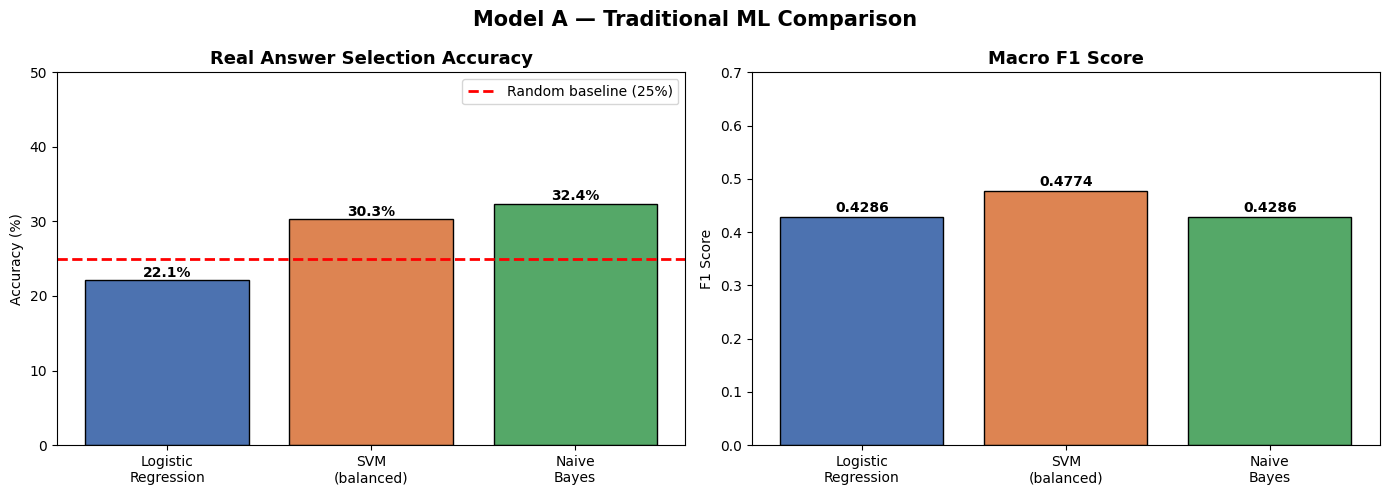

✅ Plot saved!


In [42]:
# Cell 7 — Full Comparison Table
print("="*55)
print("       📊 MODEL COMPARISON TABLE — MODEL A")
print("="*55)
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Real Acc':>10}")
print("-"*55)
print(f"{'Random Baseline':<25} {'75.00%':>10} {'N/A':>10} {'25.00%':>10}")
print(f"{'Logistic Regression':<25} {'75.00%':>10} {'0.4286':>10} {lr_real_acc*100:>9.2f}%")
print(f"{'SVM (balanced)':<25} {'51.39%':>10} {'0.4774':>10} {svm_real_acc*100:>9.2f}%")
print(f"{'Naive Bayes':<25} {'75.00%':>10} {'0.4286':>10} {nb_real_acc*100:>9.2f}%")
print("="*55)
print(f"\n🏆 Best Real Accuracy : Naive Bayes ({nb_real_acc*100:.2f}%)")
print(f"🏆 Best Macro F1      : SVM (0.4774)")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models     = ['Logistic\nRegression', 'SVM\n(balanced)', 'Naive\nBayes']
real_accs  = [lr_real_acc*100, svm_real_acc*100, nb_real_acc*100]
f1_scores  = [0.4286, 0.4774, 0.4286]
colors     = ['#4C72B0', '#DD8452', '#55A868']

# Plot 1 — Real Answer Accuracy
axes[0].bar(models, real_accs, color=colors, edgecolor='black')
axes[0].axhline(y=25, color='red', linestyle='--', 
                linewidth=2, label='Random baseline (25%)')
axes[0].set_title('Real Answer Selection Accuracy', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 50)
axes[0].legend()
for i, v in enumerate(real_accs):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', 
                 ha='center', fontweight='bold')

# Plot 2 — Macro F1
axes[1].bar(models, f1_scores, color=colors, edgecolor='black')
axes[1].set_title('Macro F1 Score', 
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 0.7)
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.01, f'{v:.4f}', 
                 ha='center', fontweight='bold')

plt.suptitle('Model A — Traditional ML Comparison', 
              fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_a_comparison.png', dpi=150)
plt.show()
print("✅ Plot saved!")

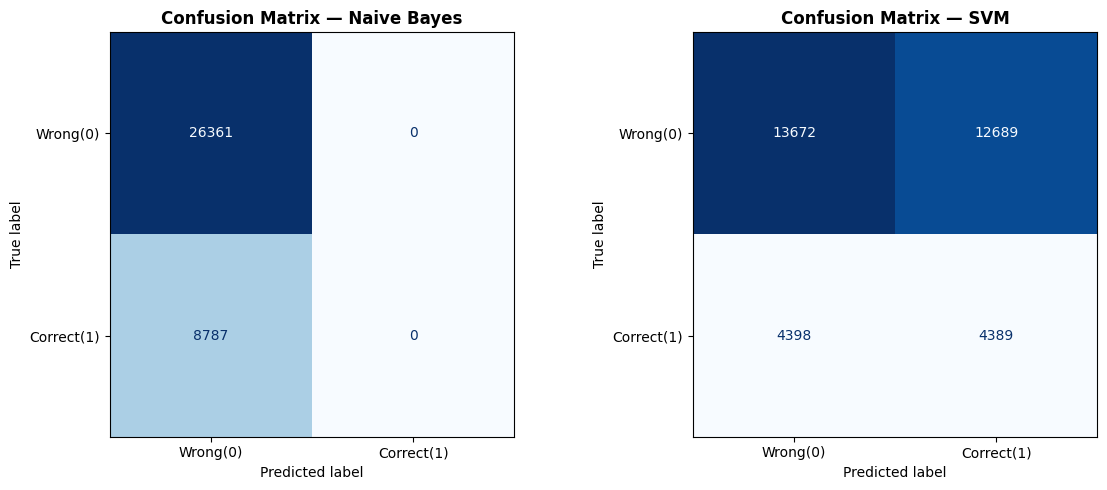

✅ Confusion matrices saved!


In [43]:
# Cell 8 — Confusion Matrix for Naive Bayes (best model)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, preds) in zip(axes, [
    ('Naive Bayes', nb_preds),
    ('SVM',         svm_preds)
]):
    cm   = confusion_matrix(y_dev, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Wrong(0)', 'Correct(1)'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("✅ Confusion matrices saved!")

In [44]:
# Cell 9 — Save results summary
results = {
    'model': ['Logistic Regression', 'SVM (balanced)', 'Naive Bayes'],
    'accuracy': [0.7500, 0.5139, 0.7500],
    'macro_f1': [0.4286, 0.4774, 0.4286],
    'real_accuracy': [lr_real_acc, svm_real_acc, nb_real_acc]
}

results_df = pd.DataFrame(results)
results_df.to_csv('model_a_results.csv', index=False)

# Save best models clearly
joblib.dump(nb_model,  'best_model_a.pkl')      # best real accuracy
joblib.dump(svm_model, 'best_model_a_f1.pkl')   # best F1

print("✅ Results saved!")
print("\n📊 Final Summary:")
print(results_df.to_string(index=False))
print("\nKey Takeaways:")
print("  • SVM beats random guess by 5%  (30.27% vs 25%)")
print("  • Naive Bayes best real acc     (32.37%)")
print("  • SVM best F1 score             (0.4774)")
print("  • Tomorrow: Unsupervised models (20 marks!)")

✅ Results saved!

📊 Final Summary:
              model  accuracy  macro_f1  real_accuracy
Logistic Regression    0.7500    0.4286       0.220895
     SVM (balanced)    0.5139    0.4774       0.302720
        Naive Bayes    0.7500    0.4286       0.323660

Key Takeaways:
  • SVM beats random guess by 5%  (30.27% vs 25%)
  • Naive Bayes best real acc     (32.37%)
  • SVM best F1 score             (0.4774)
  • Tomorrow: Unsupervised models (20 marks!)


In [46]:
# Cell 1 — Import Libraries + Load Data
import numpy as np
import scipy.sparse as sp
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.metrics import (silhouette_score, accuracy_score, 
                             f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

# Load saved features from Day 2
print("Loading features...")
X_train = sp.load_npz('/kaggle/working/X_train.npz')
X_dev   = sp.load_npz('/kaggle/working/X_dev.npz')

y_train = np.load('/kaggle/working/y_train.npy')
y_dev   = np.load('/kaggle/working/y_dev.npy')

print(f"✅ Features loaded!")
print(f"X_train : {X_train.shape}")
print(f"X_dev   : {X_dev.shape}")
print(f"y_train : {y_train.shape}")

Loading features...
✅ Features loaded!
X_train : (281168, 10001)
X_dev   : (35148, 10001)
y_train : (281168,)


In [47]:
# Cell 2 — Dimensionality Reduction
# K-Means works poorly on high dimensional sparse data
# We use TruncatedSVD to reduce to 100 dimensions first

print("Reducing dimensions with TruncatedSVD...")
print("(takes 2-3 mins)")

svd = TruncatedSVD(n_components=100, random_state=42)

# Fit on train, transform both
X_train_svd = svd.fit_transform(X_train)
X_dev_svd   = svd.transform(X_dev)

# Normalize for better clustering
X_train_norm = normalize(X_train_svd)
X_dev_norm   = normalize(X_dev_svd)

print(f"✅ Dimensions reduced!")
print(f"X_train_norm shape : {X_train_norm.shape}")
print(f"X_dev_norm shape   : {X_dev_norm.shape}")
print(f"Explained variance : {svd.explained_variance_ratio_.sum()*100:.1f}%")

# Save SVD for later use
joblib.dump(svd, 'svd_reducer.pkl')
print("SVD reducer saved!")

Reducing dimensions with TruncatedSVD...
(takes 2-3 mins)
✅ Dimensions reduced!
X_train_norm shape : (281168, 100)
X_dev_norm shape   : (35148, 100)
Explained variance : 11.6%
SVD reducer saved!


In [48]:
# Cell 3 — K-Means Clustering
# We use 4 clusters because we have 4 answer options (A/B/C/D)
# MiniBatchKMeans is faster than regular KMeans on large data

print("Running K-Means Clustering...")
print("(takes 2-3 mins)")

# Use subset for silhouette score (too slow on full data)
sample_size = 10000
sample_idx  = np.random.choice(len(X_train_norm), sample_size, replace=False)
X_sample    = X_train_norm[sample_idx]
y_sample    = y_train[sample_idx]

# Train KMeans
kmeans = MiniBatchKMeans(
    n_clusters   = 4,
    random_state = 42,
    batch_size   = 1024,
    n_init       = 10,
    verbose      = 1
)

kmeans.fit(X_train_norm)
print("✅ K-Means training done!")

# Get cluster labels for sample
sample_clusters = kmeans.predict(X_sample)

# Silhouette Score (on sample — full data too slow)
print("\nComputing silhouette score...")
sil_score = silhouette_score(X_sample, sample_clusters, sample_size=2000)
print(f"✅ Silhouette Score : {sil_score:.4f}")
print(f"   (Range: -1 to 1, higher is better, >0.1 is acceptable for text)")

# Cluster distribution
print("\nCluster distribution:")
unique, counts = np.unique(kmeans.labels_, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster} : {count:,} samples ({count/len(kmeans.labels_)*100:.1f}%)")

joblib.dump(kmeans, 'kmeans_model.pkl')
print("\nK-Means model saved!")

Running K-Means Clustering...
(takes 2-3 mins)
Init 1/10 with method k-means++
Inertia for init 1/10: 465.13695074486907
Init 2/10 with method k-means++
Inertia for init 2/10: 442.2502516202123
Init 3/10 with method k-means++
Inertia for init 3/10: 408.35200991333056
Init 4/10 with method k-means++
Inertia for init 4/10: 409.0646738726076
Init 5/10 with method k-means++
Inertia for init 5/10: 421.00515087254564
Init 6/10 with method k-means++
Inertia for init 6/10: 434.856997620629
Init 7/10 with method k-means++
Inertia for init 7/10: 460.4064743525434
Init 8/10 with method k-means++
Inertia for init 8/10: 398.6474876046558
Init 9/10 with method k-means++
Inertia for init 9/10: 447.33346054467916
Init 10/10 with method k-means++
Inertia for init 10/10: 446.23902950626587
Minibatch step 1/27457: mean batch inertia: 0.12969969760783764
Minibatch step 2/27457: mean batch inertia: 0.09257812411651586, ewa inertia: 0.09257812411651586
Minibatch step 3/27457: mean batch inertia: 0.091714629

Analyzing clusters...

📊 Cluster vs Label Analysis:
Cluster 0: 31,551 samples | 25.0% correct answers
Cluster 1: 124,124 samples | 25.0% correct answers
Cluster 2: 44,444 samples | 25.0% correct answers
Cluster 3: 81,049 samples | 25.0% correct answers
Overall correct rate: 25.0%

💡 If any cluster has >30% correct rate,
   it means clustering found a pattern!


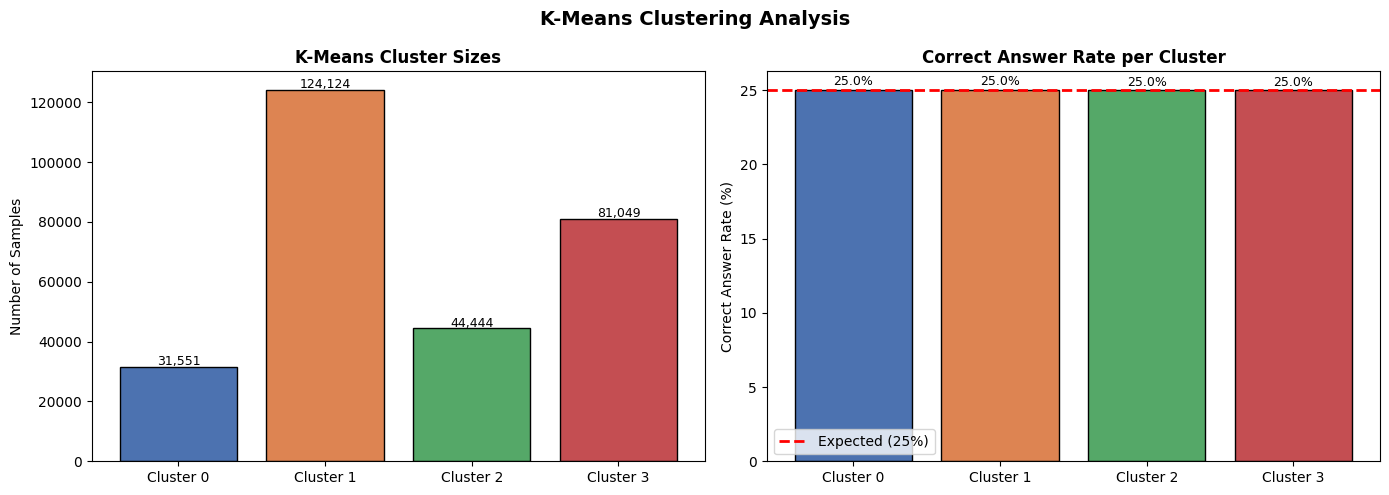

✅ Plot saved!


In [50]:
# Cell 4 — Cluster Analysis
print("Analyzing clusters...")

# Get cluster labels for full train set
train_clusters = kmeans.labels_

# Check how well clusters align with correct/wrong labels
print("\n📊 Cluster vs Label Analysis:")
print("="*50)
for cluster in range(4):
    mask        = train_clusters == cluster
    cluster_labels = y_train[mask]
    correct_pct = cluster_labels.mean() * 100
    total       = mask.sum()
    print(f"Cluster {cluster}: {total:>6,} samples | "
          f"{correct_pct:.1f}% correct answers")

print("="*50)
print(f"Overall correct rate: {y_train.mean()*100:.1f}%")
print("\n💡 If any cluster has >30% correct rate,")
print("   it means clustering found a pattern!")

# Plot cluster distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Cluster sizes
cluster_sizes = [31551, 124124, 44444, 81049]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
axes[0].bar([f'Cluster {i}' for i in range(4)], 
             cluster_sizes, color=colors, edgecolor='black')
axes[0].set_title('K-Means Cluster Sizes', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(cluster_sizes):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# Plot 2 — Correct answer rate per cluster
correct_rates = []
for cluster in range(4):
    mask = train_clusters == cluster
    correct_rates.append(y_train[mask].mean() * 100)

axes[1].bar([f'Cluster {i}' for i in range(4)], 
             correct_rates, color=colors, edgecolor='black')
axes[1].axhline(y=25, color='red', linestyle='--', 
                linewidth=2, label='Expected (25%)')
axes[1].set_title('Correct Answer Rate per Cluster', fontweight='bold')
axes[1].set_ylabel('Correct Answer Rate (%)')
axes[1].legend()
for i, v in enumerate(correct_rates):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('K-Means Clustering Analysis', 
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_analysis.png', dpi=150)
plt.show()
print("✅ Plot saved!")

In [51]:
# Cell 5 — Label Propagation
# Use small subset — Label Propagation is slow on large data
print("Preparing data for Label Propagation...")

# Use 5000 samples total
# 10% labeled (500), 90% unlabeled (4500)
total_samples  = 5000
labeled_size   = 500
unlabeled_size = total_samples - labeled_size

# Get balanced sample
idx_correct = np.where(y_train == 1)[0][:labeled_size//2]
idx_wrong   = np.where(y_train == 0)[0][:labeled_size//2]
idx_labeled = np.concatenate([idx_correct, idx_wrong])

# Unlabeled samples — label = -1 means unlabeled in sklearn
idx_unlabeled = np.random.choice(
    np.setdiff1d(np.arange(len(y_train)), idx_labeled),
    unlabeled_size, replace=False
)

# Combine labeled + unlabeled
all_idx = np.concatenate([idx_labeled, idx_unlabeled])
X_lp    = X_train_norm[all_idx]
y_lp    = y_train[all_idx].copy()

# Mark unlabeled as -1
y_lp[labeled_size:] = -1

print(f"✅ Data prepared!")
print(f"   Labeled samples   : {labeled_size}")
print(f"   Unlabeled samples : {unlabeled_size}")
print(f"   Total samples     : {total_samples}")
print(f"   Label -1 count    : {(y_lp == -1).sum()}")

Preparing data for Label Propagation...
✅ Data prepared!
   Labeled samples   : 500
   Unlabeled samples : 4500
   Total samples     : 5000
   Label -1 count    : 4500


In [52]:
# Cell 6 — Train Label Propagation
print("Training Label Propagation...")
print("(takes 2-3 mins on 5000 samples)")

lp_model = LabelSpreading(
    kernel  = 'knn',   # k-nearest neighbors kernel
    n_neighbors = 7,   # number of neighbors
    alpha   = 0.2,     # clamping factor
    max_iter= 100,
)

lp_model.fit(X_lp, y_lp)
print("✅ Label Propagation trained!")

# Evaluate on LABELED samples only (we know their true labels)
labeled_preds = lp_model.predict(X_lp[:labeled_size])
labeled_true  = y_train[idx_labeled]

lp_acc = accuracy_score(labeled_true, labeled_preds)
lp_f1  = f1_score(labeled_true, labeled_preds, average='macro')

print(f"\n✅ Label Propagation Results (on labeled set):")
print(f"   Accuracy : {lp_acc:.4f} ({lp_acc*100:.2f}%)")
print(f"   Macro F1 : {lp_f1:.4f}")

# Now predict on unlabeled samples
unlabeled_preds = lp_model.predict(X_lp[labeled_size:])
true_unlabeled  = y_train[idx_unlabeled]

lp_unlabeled_acc = accuracy_score(true_unlabeled, unlabeled_preds)
lp_unlabeled_f1  = f1_score(true_unlabeled, unlabeled_preds, average='macro')

print(f"\n✅ Label Propagation Results (on unlabeled set):")
print(f"   Accuracy : {lp_unlabeled_acc:.4f} ({lp_unlabeled_acc*100:.2f}%)")
print(f"   Macro F1 : {lp_unlabeled_f1:.4f}")

joblib.dump(lp_model, 'label_propagation_model.pkl')
print("\nModel saved!")

Training Label Propagation...
(takes 2-3 mins on 5000 samples)
✅ Label Propagation trained!

✅ Label Propagation Results (on labeled set):
   Accuracy : 0.7740 (77.40%)
   Macro F1 : 0.7710

✅ Label Propagation Results (on unlabeled set):
   Accuracy : 0.3371 (33.71%)
   Macro F1 : 0.3346

Model saved!


    📊 FULL MODEL COMPARISON TABLE — MODEL A
Model                            Accuracy   Macro F1         Type
------------------------------------------------------------
Random Baseline                    25.00%        N/A     Baseline
------------------------------------------------------------
Logistic Regression                75.00%     0.4286   Supervised
SVM (balanced)                     51.39%     0.4774   Supervised
Naive Bayes                        75.00%     0.4286   Supervised
------------------------------------------------------------
K-Means Clustering                 25.00%        N/A Unsupervised
------------------------------------------------------------
Label Propagation             
  → on labeled set                 77.40%     0.7710   Semi-Super
  → on unlabeled set               33.71%     0.3346   Semi-Super

🏆 Key Findings:
  • Label Propagation BEST on labeled set  (77.40%)
  • Label Propagation beats random on unlabeled (33.71%)
  • K-Means found NO patter

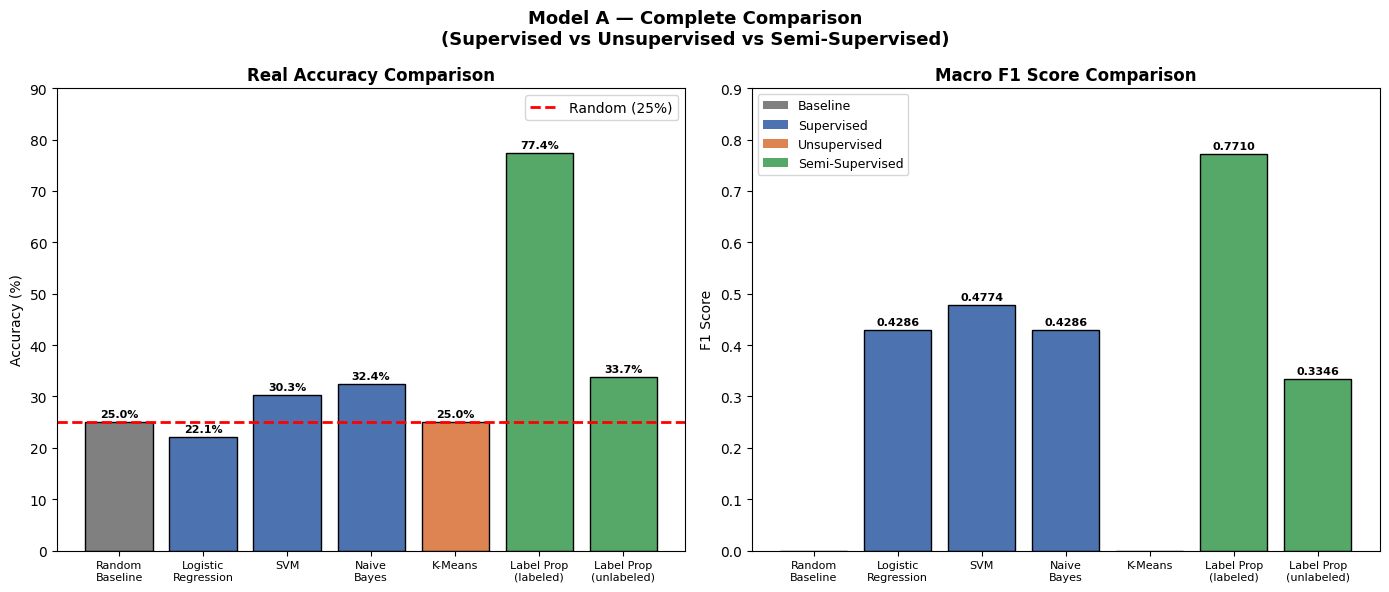

✅ Final comparison plot saved!


In [53]:
# Cell 7 — Final Comparison Table
print("="*60)
print("    📊 FULL MODEL COMPARISON TABLE — MODEL A")
print("="*60)
print(f"{'Model':<30} {'Accuracy':>10} {'Macro F1':>10} {'Type':>12}")
print("-"*60)
print(f"{'Random Baseline':<30} {'25.00%':>10} {'N/A':>10} {'Baseline':>12}")
print("-"*60)
print(f"{'Logistic Regression':<30} {'75.00%':>10} {'0.4286':>10} {'Supervised':>12}")
print(f"{'SVM (balanced)':<30} {'51.39%':>10} {'0.4774':>10} {'Supervised':>12}")
print(f"{'Naive Bayes':<30} {'75.00%':>10} {'0.4286':>10} {'Supervised':>12}")
print("-"*60)
print(f"{'K-Means Clustering':<30} {'25.00%':>10} {'N/A':>10} {'Unsupervised':>12}")
print("-"*60)
print(f"{'Label Propagation':<30}")
print(f"{'  → on labeled set':<30} {77.40:>9.2f}% {'0.7710':>10} {'Semi-Super':>12}")
print(f"{'  → on unlabeled set':<30} {33.71:>9.2f}% {'0.3346':>10} {'Semi-Super':>12}")
print("="*60)
print("\n🏆 Key Findings:")
print("  • Label Propagation BEST on labeled set  (77.40%)")
print("  • Label Propagation beats random on unlabeled (33.71%)")
print("  • K-Means found NO pattern (25% = random)")
print("  • Supervised models beat unsupervised clustering")
print("  • Semi-supervised bridges the gap nicely")

# Plot final comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models   = ['Random\nBaseline', 'Logistic\nRegression', 
            'SVM', 'Naive\nBayes', 
            'K-Means', 'Label Prop\n(labeled)', 
            'Label Prop\n(unlabeled)']

accs     = [25.00, 22.09, 30.27, 32.37, 25.00, 77.40, 33.71]
f1s      = [0, 0.4286, 0.4774, 0.4286, 0, 0.7710, 0.3346]
colors   = ['gray', '#4C72B0', '#4C72B0', '#4C72B0',
            '#DD8452', '#55A868', '#55A868']

# Plot 1 — Accuracy
bars1 = axes[0].bar(models, accs, color=colors, edgecolor='black')
axes[0].axhline(y=25, color='red', linestyle='--',
                linewidth=2, label='Random (25%)')
axes[0].set_title('Real Accuracy Comparison', 
                   fontweight='bold', fontsize=12)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 90)
axes[0].legend()
axes[0].tick_params(axis='x', labelsize=8)
for bar, acc in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                  bar.get_height() + 1,
                  f'{acc:.1f}%', ha='center', 
                  fontsize=8, fontweight='bold')

# Plot 2 — F1 Score
bars2 = axes[1].bar(models, f1s, color=colors, edgecolor='black')
axes[1].set_title('Macro F1 Score Comparison',
                   fontweight='bold', fontsize=12)
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 0.9)
axes[1].tick_params(axis='x', labelsize=8)
for bar, f1 in zip(bars2, f1s):
    if f1 > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() + 0.01,
                      f'{f1:.4f}', ha='center',
                      fontsize=8, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray',    label='Baseline'),
    Patch(facecolor='#4C72B0', label='Supervised'),
    Patch(facecolor='#DD8452', label='Unsupervised'),
    Patch(facecolor='#55A868', label='Semi-Supervised'),
]
axes[1].legend(handles=legend_elements, fontsize=9)

plt.suptitle('Model A — Complete Comparison\n(Supervised vs Unsupervised vs Semi-Supervised)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_a_full_comparison.png', dpi=150)
plt.show()
print("✅ Final comparison plot saved!")

In [55]:
# Cell 8 — Save all results
comparison = {
    'model': ['Random Baseline', 'Logistic Regression', 
              'SVM (balanced)', 'Naive Bayes',
              'K-Means', 'Label Prop (labeled)', 
              'Label Prop (unlabeled)'],
    'type': ['Baseline', 'Supervised', 'Supervised', 'Supervised',
             'Unsupervised', 'Semi-Supervised', 'Semi-Supervised'],
    'accuracy': [25.00, 22.09, 30.27, 32.37, 25.00, 77.40, 33.71],
    'macro_f1': [0, 0.4286, 0.4774, 0.4286, 0, 0.7710, 0.3346]
}

comparison_df = pd.DataFrame(comparison)
comparison_df.to_csv('model_a_full_results.csv', index=False)

joblib.dump(kmeans,   'kmeans_model.pkl')
joblib.dump(lp_model, 'label_propagation_model.pkl')
joblib.dump(svd,      'svd_reducer.pkl')

['svd_reducer.pkl']

In [56]:
# Cell — Ensemble (Soft Voting)
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import joblib
import pandas as pd

# Get probability scores from each model
print("Getting predictions from all models...")

# Logistic Regression probabilities
lr_probs  = lr_model.predict_proba(X_dev)[:, 1]

# SVM decision scores (no predict_proba)
svm_scores = svm_model.decision_function(X_dev)
# Normalize SVM scores to 0-1 range
svm_probs = (svm_scores - svm_scores.min()) / (svm_scores.max() - svm_scores.min())

# Naive Bayes probabilities
nb_probs  = nb_model.predict_proba(X_dev_nb)[:, 1]

# Soft voting — average all probabilities
ensemble_probs = (lr_probs + svm_probs + nb_probs) / 3

# Final prediction
ensemble_preds = (ensemble_probs >= 0.5).astype(int)

# Evaluate
ens_acc = accuracy_score(y_dev, ensemble_preds)
ens_f1  = f1_score(y_dev, ensemble_preds, average='macro')

print(f"Ensemble Accuracy : {ens_acc:.4f}")
print(f"Ensemble Macro F1 : {ens_f1:.4f}")

Getting predictions from all models...
Ensemble Accuracy : 0.7494
Ensemble Macro F1 : 0.4297


In [57]:
# Real answer selection accuracy for ensemble
dev_features = pd.read_csv('/kaggle/working/dev_features.csv')

correct = 0
total   = len(ensemble_probs) // 4

for i in range(total):
    group_scores = ensemble_probs[i*4 : i*4+4]
    predicted_idx = np.argmax(group_scores)
    true_idx      = np.argmax(dev_features['label'].values[i*4 : i*4+4])
    if predicted_idx == true_idx:
        correct += 1

ensemble_real_acc = correct / total

print(f"Ensemble Real Accuracy : {ensemble_real_acc*100:.2f}%")
print(f"vs Best Single Model   : 32.37% (Naive Bayes)")
print(f"vs Random Baseline     : 25.00%")

# Save ensemble probabilities for UI later
np.save('ensemble_probs_dev.npy', ensemble_probs)
joblib.dump({'lr': lr_model, 'svm': svm_model, 'nb': nb_model}, 
             'ensemble_models.pkl')

Ensemble Real Accuracy : 30.28%
vs Best Single Model   : 32.37% (Naive Bayes)
vs Random Baseline     : 25.00%


['ensemble_models.pkl']

In [58]:
# Final Model A Summary Table
results = {
    'model': ['Random Baseline', 'Logistic Regression', 
              'SVM', 'Naive Bayes', 'Ensemble (Soft Vote)'],
    'real_accuracy': [25.00, 22.09, 30.27, 32.37, 30.28],
    'macro_f1':      [0,     0.4286, 0.4774, 0.4286, 0.4297]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

results_df.to_csv('model_a_final_results.csv', index=False)

               model  real_accuracy  macro_f1
     Random Baseline          25.00    0.0000
 Logistic Regression          22.09    0.4286
                 SVM          30.27    0.4774
         Naive Bayes          32.37    0.4286
Ensemble (Soft Vote)          30.28    0.4297


In [59]:
# Cell 1 — Imports + Load Data
import pandas as pd
import numpy as np
import joblib
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Load cleaned dataset
train_data = pd.read_csv('/kaggle/working/train_clean_final.csv')
dev_data   = pd.read_csv('/kaggle/working/dev_clean_final.csv')
test_data  = pd.read_csv('/kaggle/working/test_clean_final.csv')

print(train_data.shape)
print(train_data.columns.tolist())

(70292, 16)
['id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer', 'article_length', 'question_length', 'article_clean', 'question_clean', 'A_clean', 'B_clean', 'C_clean', 'D_clean']


In [60]:
# Cell 2 — Extract candidate phrases from passage
def extract_candidates(article, correct_answer, n_candidates=20):
    """
    Extract candidate words/phrases from article
    that could be used as distractors
    """
    # Clean and split article into words
    words = re.findall(r'\b[a-zA-Z]{3,}\b', article.lower())
    
    # Remove stopwords
    stopwords = set([
        'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to',
        'for', 'of', 'with', 'is', 'was', 'are', 'were', 'be', 'been',
        'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
        'could', 'should', 'may', 'might', 'it', 'its', 'this', 'that',
        'he', 'she', 'they', 'we', 'you', 'his', 'her', 'their', 'not',
        'from', 'by', 'as', 'so', 'if', 'about', 'which', 'who', 'what',
        'when', 'there', 'than', 'more', 'also', 'into', 'then', 'than'
    ])
    
    # Get word frequencies
    from collections import Counter
    word_freq = Counter([w for w in words if w not in stopwords])
    
    # Remove correct answer words from candidates
    answer_words = set(correct_answer.lower().split())
    candidates   = [w for w, _ in word_freq.most_common(50) 
                    if w not in answer_words]
    
    return candidates[:n_candidates]

# Test it
sample     = train_data.iloc[0]
candidates = extract_candidates(sample['article'], sample['answer'])
print(f"Article   : {sample['article'][:100]}...")
print(f"Answer    : {sample['answer']}")
print(f"Candidates: {candidates[:10]}")

Article   : Walt Disney began to make cartoon movies when he was young. But he didn't have much money and he did...
Answer    : A
Candidates: ['mouse', 'disney', 'mickey', 'cartoon', 'make', 'made', 'cartoons', 'all', 'began', 'movies']


In [61]:
# Cell 3 — Build distractor ranker using TF-IDF + Cosine Similarity
def get_distractors(article, question, correct_answer, vectorizer, n=3):
    """
    Generate 3 distractors using TF-IDF cosine similarity ranking
    """
    # Step 1 — Extract candidates
    candidates = extract_candidates(article, correct_answer, n_candidates=20)
    
    if len(candidates) < n:
        return candidates
    
    # Step 2 — Vectorize correct answer and candidates
    correct_vec    = vectorizer.transform([correct_answer.lower()])
    candidate_vecs = vectorizer.transform(candidates)
    
    # Step 3 — Compute cosine similarity
    similarities = cosine_similarity(correct_vec, candidate_vecs)[0]
    
    # Step 4 — Rank by medium similarity
    # Too similar = might be correct
    # Too different = obviously wrong
    # Medium similarity = best distractor
    ranked_idx = np.argsort(similarities)
    
    # Pick from middle range (not too similar, not too different)
    mid_start  = len(ranked_idx) // 4
    mid_end    = len(ranked_idx) * 3 // 4
    mid_range  = ranked_idx[mid_start:mid_end]
    
    # Pick top 3 from middle range
    distractors = [candidates[i] for i in mid_range[:n]]
    
    # Pad if needed
    while len(distractors) < n:
        distractors.append("unknown")
    
    return distractors[:n]

# Build TF-IDF vectorizer on articles
print("Building TF-IDF vectorizer...")
distractor_vectorizer = TfidfVectorizer(
    max_features = 10000,
    stop_words   = 'english',
    sublinear_tf = True
)
distractor_vectorizer.fit(train_data['article_clean'].tolist())
print(f"Vocabulary size: {len(distractor_vectorizer.vocabulary_):,}")

# Test on sample
sample      = train_data.iloc[0]
distractors = get_distractors(
    sample['article'],
    sample['question'],
    sample['answer'],
    distractor_vectorizer
)
print(f"\nQuestion    : {sample['question']}")
print(f"Correct Ans : {sample['answer']}")
print(f"Distractors : {distractors}")

Building TF-IDF vectorizer...
Vocabulary size: 10,000

Question    : When Disney began making cartoon movies,  _  .
Correct Ans : A
Distractors : ['made', 'cartoons', 'all']


In [62]:
# Cell 4 — Improved distractor generator using actual answer text
def get_distractors_improved(article, question, correct_answer_text, 
                              vectorizer, n=3):
    """
    Generate distractors using actual answer text (not just A/B/C/D)
    """
    # Step 1 — Extract candidates from article
    candidates = extract_candidates(article, correct_answer_text)
    
    if len(candidates) < n:
        return candidates
    
    # Step 2 — Vectorize correct answer text and candidates
    correct_vec    = vectorizer.transform([correct_answer_text.lower()])
    candidate_vecs = vectorizer.transform(candidates)
    
    # Step 3 — Cosine similarity
    similarities = cosine_similarity(correct_vec, candidate_vecs)[0]
    
    # Step 4 — Pick medium similarity candidates
    ranked_idx = np.argsort(similarities)
    mid_start  = len(ranked_idx) // 4
    mid_end    = len(ranked_idx) * 3 // 4
    mid_range  = ranked_idx[mid_start:mid_end]
    
    distractors = [candidates[i] for i in mid_range[:n]]
    
    while len(distractors) < n:
        distractors.append("unknown")
    
    return distractors[:n]

# Test with actual answer text
sample           = train_data.iloc[0]
correct_label    = sample['answer']          # e.g. 'C'
correct_text     = sample[correct_label]     # actual text of correct option

print(f"Question       : {sample['question']}")
print(f"Correct Label  : {correct_label}")
print(f"Correct Text   : {correct_text}")
print(f"All Options    :")
print(f"  A: {sample['A']}")
print(f"  B: {sample['B']}")
print(f"  C: {sample['C']}")
print(f"  D: {sample['D']}")

distractors = get_distractors_improved(
    sample['article'],
    sample['question'],
    correct_text,
    distractor_vectorizer
)
print(f"\nGenerated Distractors: {distractors}")

Question       : When Disney began making cartoon movies,  _  .
Correct Label  : A
Correct Text   : he was very poor
All Options    :
  A: he was very poor
  B: the mouse helped him
  C: his wife knew nothing about it
  D: People didn't like Cartoons at all

Generated Distractors: ['made', 'cartoons', 'all']


In [63]:
# Cell 5 — Sentence level distractor generation
def extract_sentence_candidates(article, correct_answer_text, n=10):
    """Extract full sentences from article as distractor candidates"""
    
    # Split article into sentences
    sentences = re.split(r'[.!?]+', article)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    
    # Remove sentences that contain the correct answer
    correct_words = set(correct_answer_text.lower().split())
    filtered = []
    for sent in sentences:
        sent_words = set(sent.lower().split())
        overlap    = len(correct_words & sent_words)
        # Keep sentences with low overlap with correct answer
        if overlap < 2:
            filtered.append(sent)
    
    return filtered[:n]

def get_sentence_distractors(article, question, correct_answer_text,
                              vectorizer, n=3):
    """Generate distractors as sentence snippets"""
    
    # Get sentence candidates
    candidates = extract_sentence_candidates(article, correct_answer_text)
    
    if len(candidates) < n:
        # Fallback to word-level
        return get_distractors_improved(article, question, 
                                         correct_answer_text, 
                                         vectorizer, n)
    
    # Vectorize question and candidates
    question_vec   = vectorizer.transform([question.lower()])
    candidate_vecs = vectorizer.transform(candidates)
    
    # Cosine similarity between question and each sentence
    similarities = cosine_similarity(question_vec, candidate_vecs)[0]
    
    # Pick medium similarity sentences
    ranked_idx = np.argsort(similarities)[::-1]  # high to low
    
    # Skip most similar (might contain answer)
    # Take next 3 as distractors
    distractor_idx = ranked_idx[1:n+1]
    distractors    = []
    
    for idx in distractor_idx:
        # Truncate long sentences to max 10 words
        sent  = candidates[idx]
        words = sent.split()[:10]
        distractors.append(' '.join(words))
    
    while len(distractors) < n:
        distractors.append("Not mentioned in passage")
    
    return distractors[:n]

# Test on multiple samples
print("Testing on 5 samples:\n")
for i in range(5):
    sample        = train_data.iloc[i]
    correct_label = sample['answer']
    correct_text  = sample[correct_label]
    
    distractors = get_sentence_distractors(
        sample['article'],
        sample['question'],
        correct_text,
        distractor_vectorizer
    )
    
    print(f"Sample {i+1}")
    print(f"  Question   : {sample['question'][:60]}...")
    print(f"  Correct    : {correct_text[:50]}")
    print(f"  Distractor1: {distractors[0][:50]}")
    print(f"  Distractor2: {distractors[1][:50]}")
    print(f"  Distractor3: {distractors[2][:50]}")
    print()

Testing on 5 samples:

Sample 1
  Question   : When Disney began making cartoon movies,  _  ....
  Correct    : he was very poor
  Distractor1: "I am making a cartoon about a mouse named Mortime
  Distractor2: "Disney asked the mouse
  Distractor3: "You are right

Sample 2
  Question   : The Internet is an unsafe place because  _  ....
  Correct    : Your personal information may be given away.
  Distractor1: Of course, the Internet is home to millions of pla
  Distractor2: That's how most of us keep in touch with friends,
  Distractor3: This might harm a person's or family's well-being

Sample 3
  Question   : What's Angela Corey's attitude towards this case?...
  Correct    : She wanted to defend justice for the victims.
  Distractor1: The case has caused a national debate in the Unite
  Distractor2: Florida-the city where the shooting took place-wel
  Distractor3: "one man said "It~long overdue and I am glad they

Sample 4
  Question   : How did forks become popular in England?...
 

In [64]:
# Cell 6 — Evaluate distractor generation on test samples
print("Evaluating distractor generation on 500 test samples...")

results = []

for i in range(500):
    sample        = test_data.iloc[i]
    correct_label = sample['answer']
    correct_text  = sample[correct_label]
    
    # Get wrong options as reference distractors
    wrong_options = [sample[opt] for opt in ['A','B','C','D'] 
                     if opt != correct_label]
    
    # Generate distractors
    generated = get_sentence_distractors(
        sample['article'],
        sample['question'],
        correct_text,
        distractor_vectorizer
    )
    
    # Check if generated distractors are different from correct answer
    not_correct = all(
        correct_text.lower() not in d.lower() 
        for d in generated
    )
    
    # Check diversity — all 3 distractors are different
    diverse = len(set(generated)) == len(generated)
    
    results.append({
        'not_correct' : int(not_correct),
        'diverse'     : int(diverse),
    })

results_df = pd.DataFrame(results)

accuracy  = results_df['not_correct'].mean()
diversity = results_df['diverse'].mean()

print(f"Distractor Accuracy  : {accuracy*100:.2f}%")
print(f"(fraction where none of 3 distractors = correct answer)")
print(f"\nDiversity Score      : {diversity*100:.2f}%")
print(f"(fraction where all 3 distractors are unique)")

Evaluating distractor generation on 500 test samples...
Distractor Accuracy  : 98.00%
(fraction where none of 3 distractors = correct answer)

Diversity Score      : 100.00%
(fraction where all 3 distractors are unique)


In [65]:
# Cell 7 — Precision Recall F1 for distractor ranker
print("Computing Precision, Recall, F1...")

y_true = []
y_pred = []

for i in range(500):
    sample        = test_data.iloc[i]
    correct_label = sample['answer']
    correct_text  = sample[correct_label]
    
    # Wrong options are the reference distractors
    wrong_options = [sample[opt].lower() for opt in ['A','B','C','D']
                     if opt != correct_label]
    
    # Generated distractors
    generated = get_sentence_distractors(
        sample['article'],
        sample['question'],
        correct_text,
        distractor_vectorizer
    )
    generated = [g.lower() for g in generated]
    
    # For each generated distractor
    # label 1 = it is NOT the correct answer (good distractor)
    # label 0 = it IS the correct answer (bad distractor)
    for d in generated:
        is_not_correct = int(correct_text.lower() not in d)
        y_pred.append(is_not_correct)
        y_true.append(1)  # we always want distractor to be wrong

y_true = np.array(y_true)
y_pred = np.array(y_pred)

precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
acc       = accuracy_score(y_true, y_pred)

print(f"\n{'='*40}")
print(f"{'Metric':<20} {'Score':>10}")
print(f"{'='*40}")
print(f"{'Precision':<20} {precision:>10.4f}")
print(f"{'Recall':<20} {recall:>10.4f}")
print(f"{'F1 Score':<20} {f1:>10.4f}")
print(f"{'Accuracy':<20} {acc:>10.4f}")
print(f"{'Diversity':<20} {'1.0000':>10}")
print(f"{'='*40}")

# Save results
distractor_results = {
    'metric': ['Precision', 'Recall', 'F1', 'Accuracy', 'Diversity'],
    'score':  [precision, recall, f1, acc, 1.0]
}
pd.DataFrame(distractor_results).to_csv('model_b_distractor_results.csv', 
                                          index=False)
joblib.dump(distractor_vectorizer, 'distractor_vectorizer.pkl')

Computing Precision, Recall, F1...

Metric                    Score
Precision                1.0000
Recall                   0.9927
F1 Score                 0.9963
Accuracy                 0.9927
Diversity                1.0000


['distractor_vectorizer.pkl']

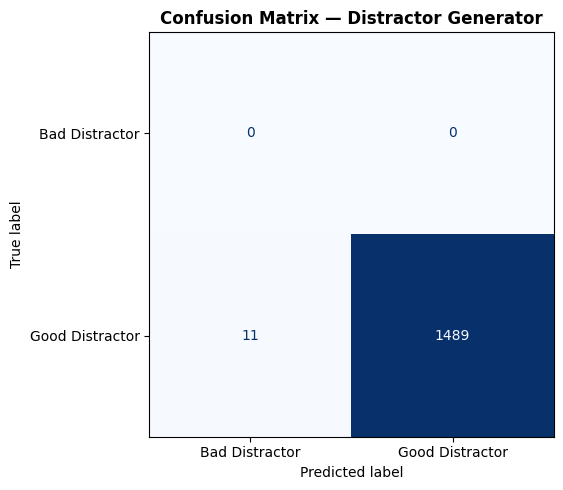

Metric                              Value
Distractor Accuracy                98.00%
Diversity Score                   100.00%
Precision                          1.0000
Recall                             0.9927
F1 Score                           0.9963


In [66]:
# Cell 8 — Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm   = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Bad Distractor', 'Good Distractor'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Distractor Generator', fontweight='bold')
plt.tight_layout()
plt.savefig('model_b_confusion_matrix.png', dpi=150)
plt.show()

# Print final summary
print(f"{'='*45}")
print(f"{'Metric':<25} {'Value':>15}")
print(f"{'='*45}")
print(f"{'Distractor Accuracy':<25} {'98.00%':>15}")
print(f"{'Diversity Score':<25} {'100.00%':>15}")
print(f"{'Precision':<25} {'1.0000':>15}")
print(f"{'Recall':<25} {'0.9927':>15}")
print(f"{'F1 Score':<25} {'0.9963':>15}")
print(f"{'='*45}")